In [1]:
color = ["#C96144", "#E99D4E", "#5185C0", "#8281B9", "#55966B", "#99C290", "#C0BEDC", "#8EA9D4", "#F2CB9F", "#99AABB", "#FFB3C1", '#FFD3E0', '#87CEEB']


/tmp/ipykernel_3555183/1419399928.py:76: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=20)


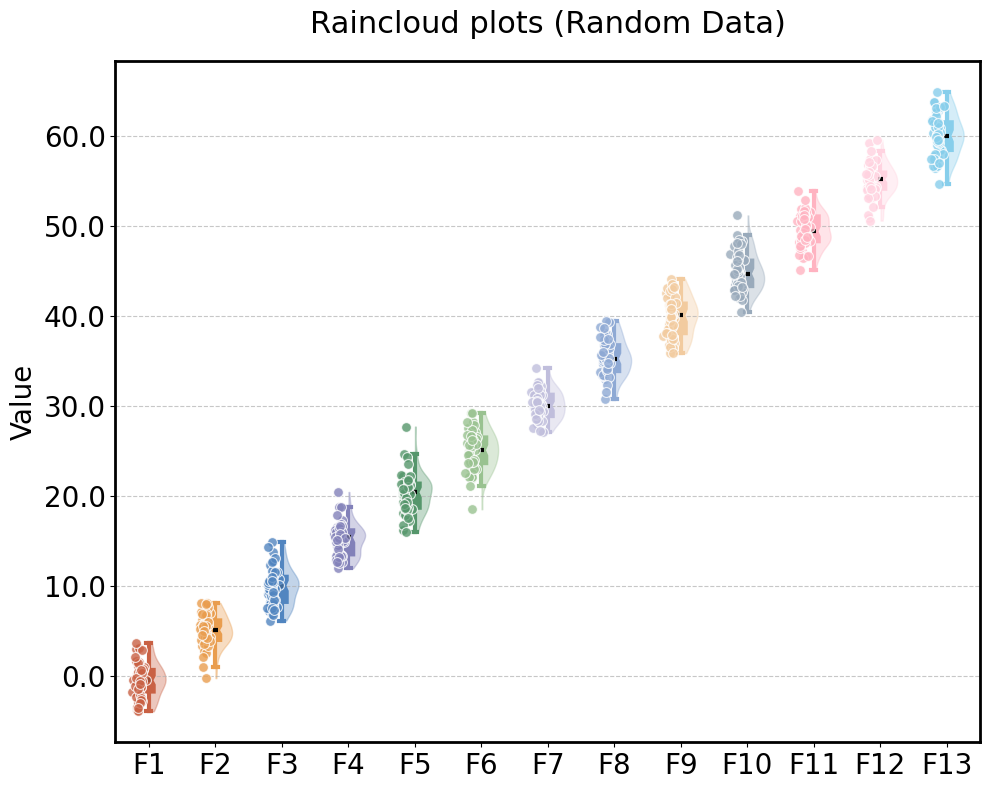

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==================== 1. 数据准备 ====================
# 类别
# 类别 - 使用颜色列表的长度来生成对应数量的类别
categories = [f'F{i+1}' for i in range(len(color))]

# 生成随机数据（正态分布，均值不同，模拟5组数据）
np.random.seed(42)  # 固定随机种子，保证可复现
df = pd.DataFrame({
    cat: np.random.normal(loc=i*5, scale=2, size=50)  # 每组50个数据点
    for i, cat in enumerate(categories)
})

# ==================== 2. 可视化设置 ====================
fig, ax = plt.subplots(figsize=(10, 8))
box_colors = violin_colors = color
positions = np.arange(len(categories))
box_width = 0.15
violin_width = 0.5

# ==================== 3. 绘制图形 ====================
for i, category in enumerate(categories):
    data_points = df[category].values

    # --- 箱线图 ---
    box_pos = positions[i] - box_width / 100
    ax.boxplot(
        data_points,
        positions=[box_pos],
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        notch=True,
        medianprops={'color': 'black', 'linewidth': 3},
        boxprops={'facecolor': box_colors[i], 'edgecolor': violin_colors[i], 'linewidth': 3},
        whiskerprops={'color': violin_colors[i], 'linewidth': 3},
        capprops={'color': violin_colors[i], 'linewidth': 3}
    )

    # --- 半小提琴图 ---
    violin_pos = positions[i] + box_width / 50
    violin = ax.violinplot(
        data_points,
        positions=[violin_pos],
        widths=violin_width,
        showmeans=False,
        showmedians=False,
        showextrema=False
    )
    for pc in violin['bodies']:
        pc.set_facecolor(violin_colors[i])
        pc.set_edgecolor(violin_colors[i])
        pc.set_alpha(0.35)
        vertices = pc.get_paths()[0].vertices
        vertices[:, 0] = np.where(vertices[:, 0] > violin_pos, vertices[:, 0], violin_pos)

    # --- 数据散点 ---
    ax.scatter(
        np.random.normal(positions[i] - box_width, 0.04, len(data_points)),
        data_points,
        color=violin_colors[i],
        alpha=0.8,
        s=50,
        edgecolor='white',
        linewidth=0.8,
        zorder=3
    )

# ==================== 4. 图表美化 ====================
ax.set_xticks(positions)
ax.set_xticklabels(categories, fontsize=20)
ax.set_ylabel('Value', fontsize=20)
ax.set_yticklabels(ax.get_yticks(), fontsize=20)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for spine in ['top', 'right', 'bottom', 'left']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(2)
    ax.spines[spine].set_color('black')

plt.title('Raincloud plots (Random Data)', pad=20, fontsize=22)
plt.tight_layout()
plt.show()
